In [1]:
import numpy as np
import matplotlib.pyplot as plt
# based on “Optimization of the time-dependent traveling salesman problem with Monte-Carlo methods”,
# Bentner et al., Phys.Rev. E, 64, 036701

In [2]:

def travel_dist(points,matrix): # = Hamiltonian
    N = len(points)-1
    dist = matrix[points[N],points[0]]
    for  z in range(N):
        dist += matrix[points[z],points[z+1]]
    return dist

def exchange_two_parts(x1,x2,y1,y2,array): 
    """ exchange the position [0,...,x1,...,x2,....,y1,...y2,...] to [0,...,y1,...,y2,....,x1,...x2,...]
        or vice-versa. x1 = x2 or y1 =y2 are possible
    """
    if x1 < y1:
        if x1 > 0:
            change = np.concatenate((array[0:x1],array[y1:y2+1], array[x2+1:y1], array[x1:x2+1], array[y2+1:]))
        else:
            change = np.concatenate((array[y1:y2+1], array[x2+1:y1], array[x1:x2+1], array[y2+1:]))
    else:
        if y1 > 0:
            change = np.concatenate((array[0:y1],array[x1:x2+1], array[y2+1:x1], array[y1:y2+1], array[x2+1:]))
        else:
            change = np.concatenate((array[x1:x2+1], array[y2+1:x1], array[y1:y2+1], array[x2+1:]))
    return change

def Lin_3_Opt (way):
    """
    Lin-3-Opt  exchanges two random successive parts of the tour without altering their directions.
    """
    candidates =np.array([])
    while len(candidates)==0:
        a1 = np.random.randint(len(way))
        a2 = np.random.randint(len(way))
        positions = np.arange(len(way))
        if a1 < a2:
            x1 = a1
            x2 = a2
        else:
            x1 = a2
            x2 = a1

        ind = (positions < x1) | (positions > x2)
        candidates = positions[ind]

    b1 = int(np.random.choice(candidates))
    
    if b1 < x1:
        b2 = int(np.random.choice(positions[:x1]))
    else: 
        b2 = int( np.random.choice(positions[x2+1:]))
        
    if b1 < b2:
            y1 = b1
            y2 = b2
    else:
            y1 = b2
            y2 = b1

    return way[exchange_two_parts(x1,x2,y1,y2,positions)]

def Lin_2_Opt(way):
    """
    Lin-2-Opt move simply reverses the direction of a
    part of the tour  
    """
    a1 = 0
    a2 = 0
    while a1==a2:
        a1 = np.random.randint(len(way))
        a2 = np.random.randint(len(way))
    positions = np.arange(len(way)) 
    if a1 < a2:
        x1 = a1
        x2 = a2
    else:
        x1 = a2
        x2 = a1
    change = np.concatenate((positions[0:x1], positions[x1:x2+1][::-1], positions[x2+1:]))
    return way[change]
        

In [8]:
def traveling(points, matrix, steps, T=1, alpha = 1):
    """
    Time independent traveling salesman with toggable temperature and temperature reduction (0.8<alpha<0.999)
    """
    
    cost = np.zeros(steps+1)
    temp = np.zeros(steps+1)
    C = np.zeros(steps+1)
    start = points
    summ = travel_dist(start, matrix)
    cost[0] = summ
    temp[0] = T
    C[0] = np.var(cost)/T**2
    
    for tries in range(steps):
        
        method = np.random.choice(2) # choose if you use Lin
        if method ==1:
            new_start = Lin_2_Opt(start)
        else:
            new_start = Lin_3_Opt(start)
        new_sum = travel_dist(new_start, matrix)
        if np.random.uniform(low=0, high=1) < np.exp((summ-new_sum)/T):
            start = new_start
            summ = travel_dist(new_start, matrix)
        cost[tries+1] = summ
        C[tries+1] = np.var(cost)/T**2
        temp[tries+1] = T
        T = alpha*T     
    return start, summ, cost, temp, C

In [9]:
matrix =np.array([[10,2,10,1],[2,10,3,5],[10,3,10,2],[1,5,2,10]])
points = np.arange(4)


In [10]:
Tstart = 10*max(traveling(points, matrix,500,T=100000)[2])

time_ind = traveling(points, matrix,100,T=Tstart, alpha=0.85)
time_ind

(array([1, 0, 3, 2]),
 np.int64(8),
 array([ 8.,  8., 19.,  8.,  8.,  8., 19., 19., 19.,  8., 19., 19.,  8.,
        19.,  8.,  8.,  8., 19.,  8.,  8.,  8., 19., 19.,  8.,  8.,  8.,
         8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
         8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
         8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
         8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
         8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
         8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.]),
 array([1.90000000e+02, 1.90000000e+02, 1.61500000e+02, 1.37275000e+02,
        1.16683750e+02, 9.91811875e+01, 8.43040094e+01, 7.16584080e+01,
        6.09096468e+01, 5.17731998e+01, 4.40072198e+01, 3.74061368e+01,
        3.17952163e+01, 2.70259339e+01, 2.29720438e+01, 1.95262372e+01,
        1.65973016e+01, 1.41077064e+01, 1.19915504e+01, 1.01928179e+01,
        8.66389518e+00, 7.3643109

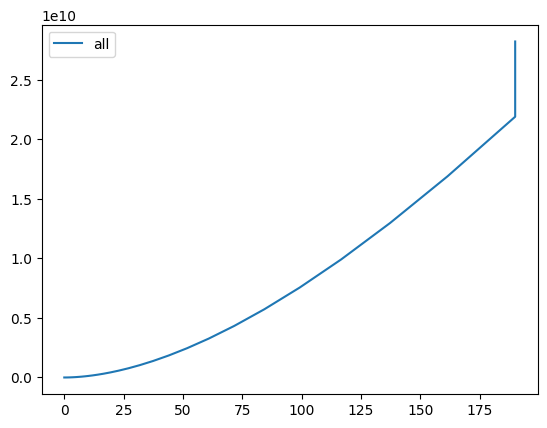

In [11]:
t = np.arange(len(time_ind[2]))
plt.plot(time_ind[3][::-1],time_ind[4], label ='all')
#plt.xscale('log')
plt.legend()

## Time dependent

In [12]:
def travel_dist_time(points,matrix): # = Hamiltonian
    N = len(points)-1
    dist = matrix[points[N],points[0],N]
    for  z in range(len(points)-1):
        dist += matrix[points[z],points[z+1],z]
    return dist

In [13]:
def traveling_time(points, matrix, steps, T=1, alpha =1):
    """
    Time independent traveling salesman with toggable temperature and temperature reduction (0.8<alpha<0.999)
    """
    
    cost = np.zeros(steps+1)
    temp = np.zeros(steps+1)
    C = np.zeros(steps+1)
    start = points
    summ = travel_dist_time(start, matrix)
    cost[0] = summ
    temp[0] = T
    C[0] = np.var(cost)/T**2
    
    for tries in range(steps):
        
        method = np.random.choice(2) # choose if you use Lin_2 or Lin_3
        if method ==1:
            new_start = Lin_2_Opt(start)
        else:
            new_start = Lin_3_Opt(start)
        new_sum = travel_dist_time(new_start, matrix)
        if np.random.uniform(low=0, high=1) < np.exp((summ-new_sum)/T):
            start = new_start
            summ = travel_dist_time(new_start, matrix)
        cost[tries+1] = summ
        C[tries+1] = np.var(cost)/T**2
        temp[tries+1] = T
        T = alpha*T     
    return start,summ, cost, temp,C

In [14]:
matrix2 =np.array([[[10,2,10,1],[2,10,3,5],[10,3,10,2],[1,5,2,10]],
                  [[10,20,10,1],[20,10,30,5],[10,30,10,2],[1,5,2,10]],
                  [[10,3.4,2,1],[3.4,10,0.2,5],[2,0.2,10,2],[1,5,2,10]],
                  [[10,10,10,0.01],[10,10,2,10],[10,2,10,10],[0.01,10,10,10]]])
points = np.arange(4)


In [15]:
travel_dist_time(points,matrix2)

np.float64(34.01)

In [16]:
traveling_time(points, matrix2, 50, T=1, alpha =1)

(array([1, 3, 2, 0]),
 np.float64(10.0),
 array([34.01, 22.  , 18.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  ,
        10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  ,
        10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  ,
        10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  ,
        10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  , 10.  ,
        10.  , 10.  , 10.  , 10.  , 10.  , 10.  ]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([22.23529604, 30.96407728, 36.41722607, 37.77047482, 39.04683007,
        40.24629181, 41.36886005, 42.41453479, 43.38331603, 44.27520377,
        45.090198  , 45.82829873, 46.48950596, 47.07381968, 47.58123991,
        48.01176663, 48.36539985, 48.64213956, 48.84198577, 48.96493849,
        49.01099769, 48.980163